# Driver Behavior - Random Forest Model
This notebook trains and evaluates a Random Forest model using the shared preprocessing artifacts (train/val/test splits).

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
ARTIFACTS_DIR = Path("artifacts")
REQUIRED = [
    "X_train.csv",
    "X_val.csv",
    "X_test.csv",
    "y_train.csv",
    "y_val.csv",
    "y_test.csv",
    "label_encoder.joblib",
]
missing = [name for name in REQUIRED if not (ARTIFACTS_DIR / name).exists()]
if missing:
    raise FileNotFoundError(
        f"Missing preprocessing artifacts: {missing}. Run driver_behavior_preprocessing.ipynb first."
    )

FileNotFoundError: Missing preprocessing artifacts: ['X_train.csv', 'X_val.csv', 'X_test.csv', 'y_train.csv', 'y_val.csv', 'y_test.csv', 'label_encoder.joblib']. Run driver_behavior_preprocessing.ipynb first.

In [ ]:
X_train = pd.read_csv(ARTIFACTS_DIR / "X_train.csv")
X_val = pd.read_csv(ARTIFACTS_DIR / "X_val.csv")
X_test = pd.read_csv(ARTIFACTS_DIR / "X_test.csv")

y_train = pd.read_csv(ARTIFACTS_DIR / "y_train.csv").iloc[:, 0].values
y_val = pd.read_csv(ARTIFACTS_DIR / "y_val.csv").iloc[:, 0].values
y_test = pd.read_csv(ARTIFACTS_DIR / "y_test.csv").iloc[:, 0].values

label_encoder = joblib.load(ARTIFACTS_DIR / "label_encoder.joblib")
class_names = label_encoder.classes_

print("Train/Val/Test sizes:", X_train.shape, X_val.shape, X_test.shape)
print("Classes:", class_names)

Train/Val/Test sizes: (21000, 10) (4500, 10) (4500, 10)
Classes: ['Aggressive' 'Distracted' 'Safe']


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

Accuracy: 1.0000
Macro F1: 1.0000
Weighted F1: 1.0000
Balanced Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

  Aggressive       1.00      1.00      1.00      1500
  Distracted       1.00      1.00      1.00      1500
        Safe       1.00      1.00      1.00      1500

    accuracy                           1.00      4500
   macro avg       1.00      1.00      1.00      4500
weighted avg       1.00      1.00      1.00      4500



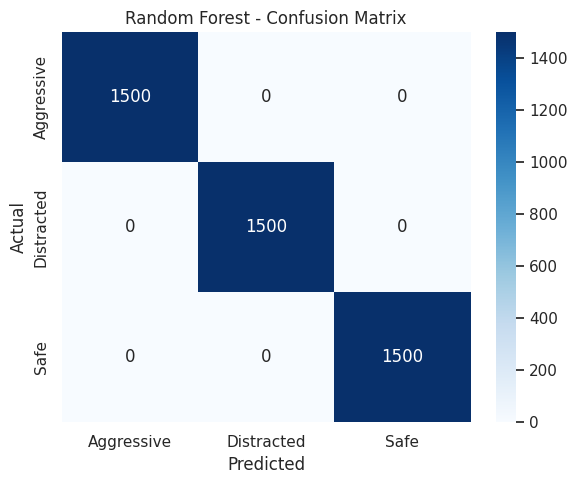

In [ ]:
acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")
bal_acc = balanced_accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

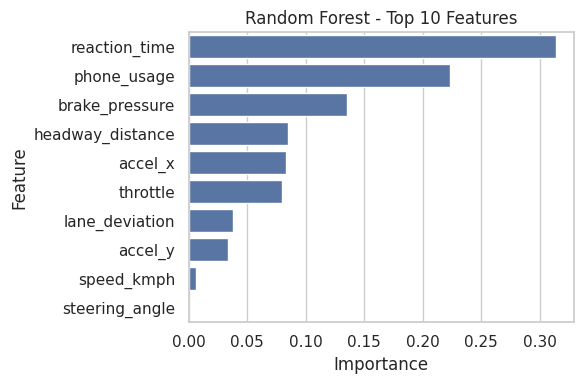

In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(6, 4))
sns.barplot(x=top.values, y=top.index)
plt.title("Random Forest - Top 10 Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
metrics_df = pd.DataFrame([
    {
        "model": "Random Forest",
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "balanced_accuracy": bal_acc,
    }
])
display(metrics_df)

joblib.dump(rf_model, ARTIFACTS_DIR / "random_forest.joblib")
metrics_df.to_csv(ARTIFACTS_DIR / "random_forest_metrics.csv", index=False)

print("Saved model and metrics to", ARTIFACTS_DIR.resolve())

,model,accuracy,macro_f1,weighted_f1,balanced_accuracy
0,Random Forest,1.0,1.0,1.0,1.0


Saved model and metrics to /home/rithik-ca/Documents/Machine Learning Projects/driver project/artifacts
